<a href="https://colab.research.google.com/github/forSplinter/free_llm_2026_Intership/blob/dev/EDA_Preprocesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

#replace with the project folder e.g 'free/LLM_free_2O26/xxxxx'
FOLDERNAME = 'free_LLM_2026/technical_test'
assert FOLDERNAME is not None
PROJECT_DIR = f"/content/drive/MyDrive/{FOLDERNAME}"

import sys
sys.path.append(PROJECT_DIR)

Mounted at /content/drive


# Prepare the datasets

In [2]:
%cd $PROJECT_DIR

from IPython.utils.text import string
import pandas as pd
import sqlite3
import os

def db_loader_csv(db_dir: str, table: str, csv_output:str) -> pd.DataFrame :
  assert os.path.exists(db_dir)

  conn = sqlite3.connect(db_dir)
  df = pd.read_sql_query(f"SELECT * FROM {table};", conn)
  conn.close()

  if csv_output:
    os.makedirs(os.path.dirname(csv_output), exist_ok=True)
    df.to_csv(csv_output, index=False)
    print(f'CSV convertion complete =>', {csv_output})

  return df

/content/drive/MyDrive/free_LLM_2026/technical_test


In [3]:
db_dir = os.path.abspath('db.sqlite')
csv_dir = os.path.abspath('data/csat_extract.csv')
table = 'csat_extract'
df = db_loader_csv(db_dir,table, csv_dir)

CSV convertion complete => {'/content/drive/MyDrive/free_LLM_2026/technical_test/data/csat_extract.csv'}


# Dataset basics

In [5]:
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
sns.set_context('notebook')
sns.set_palette('flare')
sns.set_style(style='whitegrid')

In [7]:
df.head()

,contact_id,id_profil,id_conseiller,date_contact,csat,nps,nom_departement,nom_region,du_societe_label,canal,offer_label,commentaire
0,49391456,20596135,135088.0,2025-10-19,3,6,\N,\N,\N,None,24: Freebox Pop | 39.99€,on donne toutes les infos à l’engagement et im...
1,49390924,15350417,135088.0,2025-10-19,4,7,\N,\N,\N,None,09: Freebox Révolution Light | 29.99€,"Saisi du Rio pas claire. Minuscule, pas Minusc..."
2,49390481,75269147,135088.0,2025-10-19,5,8,\N,\N,\N,None,28: Série Spéciale Freebox Pop S | 23.99€,Il manque la possibilité de choisir une date d...
3,49389164,24194380,135088.0,2025-10-19,5,9,\N,\N,\N,None,24: Freebox Pop | 39.99€,MERCI
4,49389166,48737310,135088.0,2025-10-19,4,8,\N,\N,\N,None,24: Freebox Pop | 39.99€,Il manque peut-être des précisions sur la pris...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38303 entries, 0 to 38302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   contact_id        38303 non-null  int64  
 1   id_profil         38303 non-null  int64  
 2   id_conseiller     20000 non-null  float64
 3   date_contact      38303 non-null  object 
 4   csat              38303 non-null  int64  
 5   nps               38303 non-null  object 
 6   nom_departement   34966 non-null  object 
 7   nom_region        34966 non-null  object 
 8   du_societe_label  38303 non-null  object 
 9   canal             6927 non-null   object 
 10  offer_label       21149 non-null  object 
 11  commentaire       38302 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 3.5+ MB


In [9]:
df.shape

(38303, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38303 entries, 0 to 38302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   contact_id        38303 non-null  int64  
 1   id_profil         38303 non-null  int64  
 2   id_conseiller     20000 non-null  float64
 3   date_contact      38303 non-null  object 
 4   csat              38303 non-null  int64  
 5   nps               38303 non-null  object 
 6   nom_departement   34966 non-null  object 
 7   nom_region        34966 non-null  object 
 8   du_societe_label  38303 non-null  object 
 9   canal             6927 non-null   object 
 10  offer_label       21149 non-null  object 
 11  commentaire       38302 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 3.5+ MB


# EDA and Prepocessing

Avant d'aller plus loin il nous incombe de décrire notre dataset pour mieux le comprendre il est composé comme un peu le voir plus au de 12 collonnes et de près de 38000 ligne. on y retrouve entre autre des valeurs ausi bien continue que categoritielles.
* **contact_id** : qui permet d'identifier les différentes  interactions cliente
* **id_profil**: le profil utilisateur donc du client
* **id_conseiller**: identifie le conseiller qui a pris contact avec le client
* **date_contact**: la date de l'interaction
* **csat**: l'indice de satisfaction client
* **nps**:  Pourcentage ou valeur indiquant le Net Promoter Score, permet de déterminer si un client serais pret a recommander l'entreprise
* **nom_departement**: le nom du département ou le contact a eu lieu
* **nom_region**: la région
* **du_societe_label**: le nom de la société de service client qui a pris contact avec le client
* **canal**: le canal d'acquisiton de la demande cliente
* **offer_label**: l'offre proposé ou dont le client et le service client on discuté
* **commentaire**: des avis, des problème lié soit a une offre, une demande plus générale ou encore un formulaire de satisfaction


## Missing Values

Après une bref exploration en faisant quelques requete sql dans un outils dédié il s'emblerais que l'encodage des valeus soit assez différentes selon les case pour y rémider il faut les parser avec des valeurs que comprend pandas

In [11]:
df.replace(["\\N", "nan","NaN"], np.nan, inplace = True)
p_missing_value = df.isnull().sum()*100 / len(df)
p_missing_value.sort_values(ascending=False)

,0
nom_departement,87.940892
nom_region,87.940892
canal,81.915255
du_societe_label,48.962222
id_conseiller,47.784769
offer_label,44.785004
nps,9.599770
commentaire,0.002611
date_contact,0.000000
id_profil,0.000000


Il semble avoir une forte absence de donnée notamment dans les partie nom_departement, nom_region et canal. Une stratégie que l’on pourrait envisager, mais qui n’est pas pertinente ici compte tenu de la taille du dataset et du pourcentage élevé de valeurs manquantes, serait de remplir les valeurs manquantes avec le mode (valeur la plus fréquente). Cela introduirait en effet un biais important. La meilleure approche reste de conserver ces colonnes, en partie a cause des insights métier. Il convient donc de garder les catégories les plus prédominantes et de regrouper le reste sous la catégorie "Others".

Pour commentaire on vas juste drop la colonne
Pour nps on appliquera une stratégie différente dont je parle dans la prochaine section

In [14]:
#we need to drop any column without comment
df = df.dropna(subset=['commentaire'])
df.shape

(38302, 12)

In [15]:
for col in ['nom_departement', 'nom_region', 'canal', 'du_societe_label', 'offer_label']:
  df[col] = df[col].fillna('unknown')

In [16]:
for col in ['nom_departement', 'nom_region', 'offer_label', 'du_societe_label', 'canal']:
  counts = df[col].value_counts()
  _ = counts[counts < 50].index
  df[col] = df[col].replace(_, 'Other')

* df.nps = NaN les NaN seront remplacé par les valeurs les plus fréquentes on ne risque pas de troubler la distribution, en effet la valeur 10 est prédominante sur toute les autres et nous avons un tot moindre de valeur manquante seulement 9%.

Text(0, 0.5, 'Count')

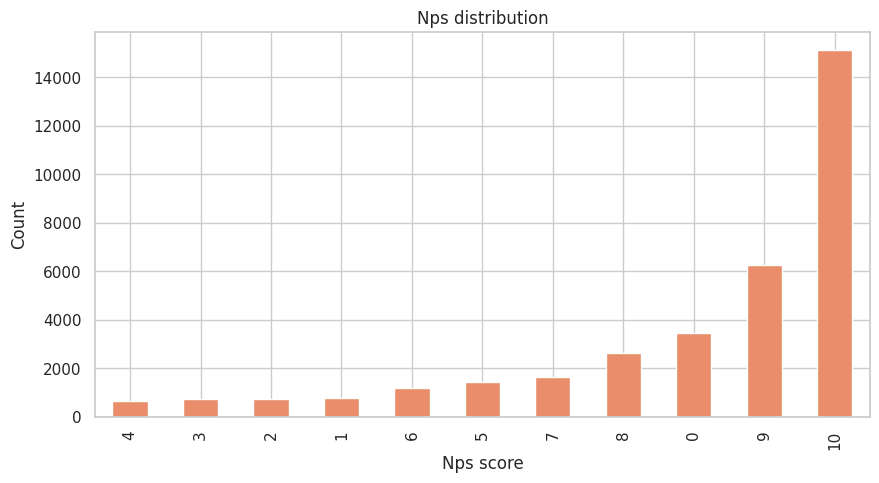

In [20]:
ax = df['nps'].value_counts().sort_values()\
    .plot(kind='bar', title='Nps distribution',
          figsize=(10, 5),)
ax.set_xlabel('Nps score')
ax.set_ylabel('Count')

In [21]:
df['nps'] = df['nps'].fillna(df['nps'].mode()[0])
df['nps'].value_counts()

,count
nps,
10,18790
9,6284
0,3447
8,2627
7,1635
5,1457
6,1182
1,764
2,739


In [22]:
df['id_profil'].value_counts()

,count
id_profil,
82174691,2
85523216,2
82875275,2
62741286,2
28973658,2
...,...
37094136,1
41059917,1
39812044,1


Avant d'aller plus loin on vas procéder a notre premier drop de valeurs, contact_id, id_profil et id_conseiller ne m'intéresse pas forcément. notre but n'est pas de faire une analyse sur la performance des conseiller chez free même ci oui il rentre en jeu dans la satisfaction cliente. Et l'id profil n'apporte rien les meme client revienne au plus 2 fois.

In [23]:
#drop column
df = df.drop(columns=['contact_id', 'id_profil', 'id_conseiller'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38302 entries, 0 to 38302
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_contact      38302 non-null  datetime64[ns]
 1   csat              38302 non-null  int64         
 2   nps               38302 non-null  object        
 3   nom_departement   38302 non-null  object        
 4   nom_region        38302 non-null  object        
 5   du_societe_label  38302 non-null  object        
 6   canal             38302 non-null  object        
 7   offer_label       38302 non-null  object        
 8   commentaire       38302 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 2.9+ MB


## Feature distribution

In [24]:
#convert date_contact in datetime
df['date_contact'] = pd.to_datetime(df['date_contact'], format='%Y-%m-%d')

In [25]:
#let's split or dataset by category
df.columns

Index(['date_contact', 'csat', 'nps', 'nom_departement', 'nom_region',
       'du_societe_label', 'canal', 'offer_label', 'commentaire'],
      dtype='object')

In [26]:
for col in ['nom_departement', 'nom_region', 'canal',
                 'du_societe_label', 'offer_label', 'nps', 'commentaire']:
                 df[col] = df[col].astype('category')

In [28]:
df['csat'].describe()

,csat
count,38302.000000
mean,4.120020
std,1.485043
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


La satisfaction cliente est plus tot bonne, on à moins de 25% de nos clients qui donne une satisfaction moindre que 4, mais il on néammoins un écart-type assez important 1.48 cela nous sugère que certaine expérience client sont vraiment négatif  

Text(0, 0.5, 'Count')

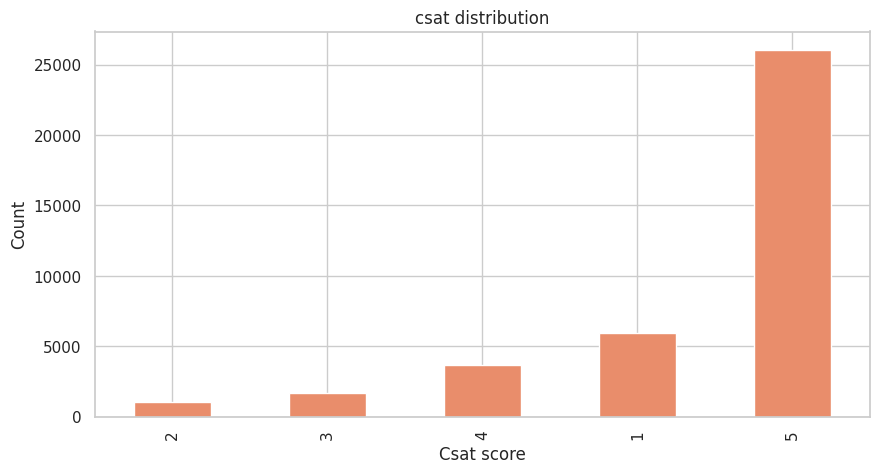

In [31]:
#let see the repartition of this variable
ax = df['csat'].value_counts().sort_values() \
    .plot(kind='bar', title='csat distribution',
          figsize=(10, 5),)
ax.set_xlabel('Csat score')
ax.set_ylabel('Count')

la majorité des valeurs sont situé au niveau de 5 globalement les clients sont satisfait, il serait judicieux dans notre analyse de comprendre ce qui pousse les clients à mettre une note aussi élevé mais aussi pourquoi, on a des notes aussi basse.

Un autre score qui apporte une insight assez pertinente sur la satisfaction cliente reste le nps

Text(0, 0.5, 'Count')

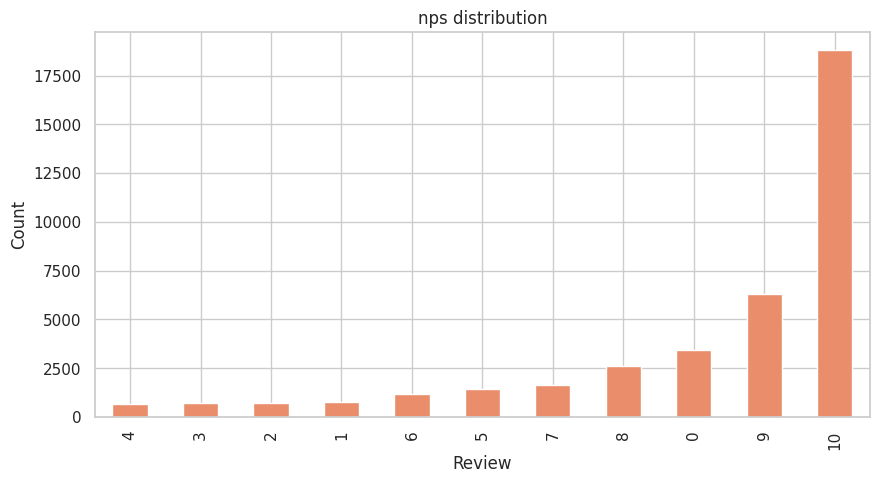

In [34]:
#let see the repartition of this variable
ax = df['nps'].value_counts().sort_values() \
    .plot(kind='bar', title='nps distribution',
          figsize=(10, 5),)
ax.set_xlabel('Review')
ax.set_ylabel('Count')

Néammoins cela ne suffit pas le nps est la plus part du temps segmentez, un client qui mettrais 6 n'est par exemple pas inclin a promouvoir vos service. Il faut donc une analyse plus fine pour comprendre

* Detractor: score entre 0-6 signe d'une mauvaise expérience client
* Passif: score entre 7-8 ses personne souvent plus enclin se tourner vers la concurence c'est un noyeau dure qu'il faut essayer de transformer en promoter
* Promoter: score entre 9-10, client satisfait des services, près recommander à nos service et nos produits

In [35]:
def nps_segment(score):
  if score <= 6:
    return 'Detractor'
  elif score <= 8:
    return 'Passif'
  else:
    return 'Promoter'


df['nps_segment'] = df['nps'].astype(float).apply(nps_segment)
df['nps_segment'].value_counts()

,count
nps_segment,
Promoter,25074
Detractor,8966
Passif,4262


Text(0, 0.5, 'Count')

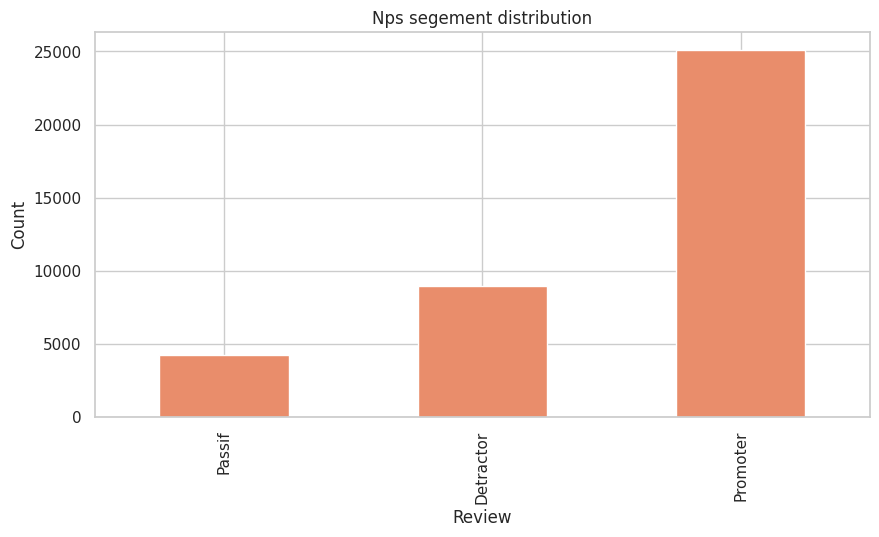

In [38]:
#let see the repartition of this variable
ax = df['nps_segment'].value_counts().sort_values() \
    .plot(kind='bar', title='Nps segement distribution',
          figsize=(10, 5),)
ax.set_xlabel('Review')
ax.set_ylabel('Count')

Grosso modo on à 23% de personne qui sont classé dans la partie detractor 11% en passsif et le reste en promoter, on pourait s'arreter la mais dans un soucis d'amékioration continue on souhaite transformer nos detracteur en promoteur pour conserver nos client et ne pas laissez s'échapper les passif il faut donc comprendre leur besoin

voyons voir si nps_segmen et CSAT sont croisez et correspondant mieux au niveau de satisfaction

In [39]:
df.groupby('nps_segment')['csat'].describe()

,count,mean,std,min,25%,50%,75%,max
nps_segment,,,,,,,,
Detractor,8966.0,2.248494,1.570871,1.0,1.0,1.0,4.0,5.0
Passif,4262.0,4.349132,0.929641,1.0,4.0,5.0,5.0,5.0
Promoter,25074.0,4.750299,0.825201,1.0,5.0,5.0,5.0,5.0


* Les détracteurs sont principalement insatisfaits, mais une minorité parmi eux a tout de même accordé des scores CSAT plus élevés 75% d'entre eux on mis un score de 4. Cela pourrait indiquer que, malgré des problèmes sous-jacents, certains aspects du produit ou service sont reconnus et appréciés par ces clients.

* Les passifs, quant à eux, affichent une satisfaction générale mais ne ressentent pas assez d’enthousiasme pour accorder une note plus élevée. En effet, bien que leur score moyen soit de 4, cela ne suffit pas pour les classer comme promoteurs.

* La majorité des clients se déclarent très satisfaits, ce qui se traduit par des scores NPS élevés, généralement entre 9 et 10. Cela montre qu’un nombre significatif de clients est enthousiaste à l’égard de leur expérience.

il est essentiel de nuancer cette observation. Un score élevé ne garantit pas nécessairement un NPS optimal, comme le prouve la présence de scores CSAT relativement élevés parmi les passifs ou les detractor tout n'est pas binaire (soit on aime soit on aime pas).

La satisfaction des clients est plus complexe et elle ne dépend pas uniquement de la moyenne des scores. Les expériences peuvent varier considérablement d'un client à l'autre, rendant nécessaire une analyse plus fine des commentaires laissés.

Text(0, 0.5, 'Count')

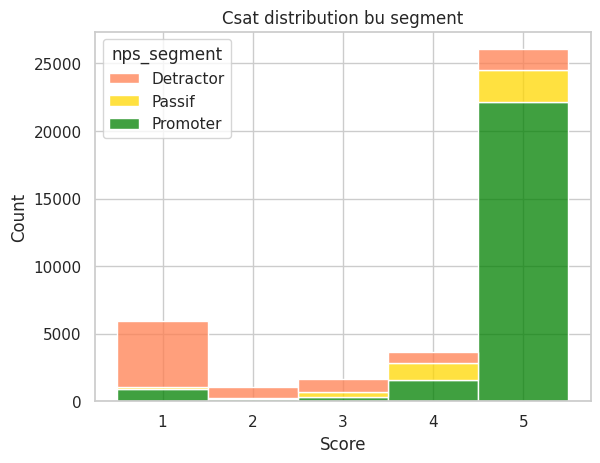

In [50]:
sns.histplot(data=df, x='csat', hue='nps_segment', multiple='stack',
             bins=5, palette={'Detractor': 'coral', 'Passif': 'gold', 'Promoter': 'green'},
             discrete=True)
plt.title('Csat distribution bu segment')
plt.xlabel('Score')
plt.ylabel('Count')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38302 entries, 0 to 38302
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_contact      38302 non-null  datetime64[ns]
 1   csat              38302 non-null  int64         
 2   nps               38302 non-null  category      
 3   nom_departement   38302 non-null  category      
 4   nom_region        38302 non-null  category      
 5   du_societe_label  38302 non-null  category      
 6   canal             38302 non-null  category      
 7   offer_label       38302 non-null  category      
 8   commentaire       38302 non-null  category      
 9   nps_segment       38302 non-null  object        
dtypes: category(7), datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ MB


In [55]:
df_num = df.select_dtypes(include='int64')

<Axes: >

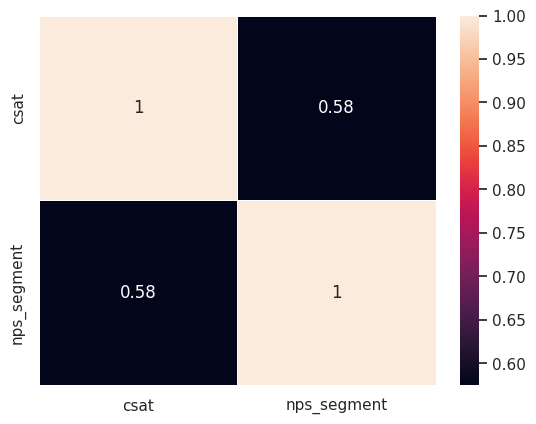

In [66]:
#Corr
mapping = {
    "Detractor": -100,
    "Passif": 0,
    "Promotor": 100
}
df_num['nps_segment'] = df['nps_segment'].map(mapping)
sns.heatmap(df_num[['csat', 'nps_segment']].corr("pearson"),
            annot=True, linewidths=0.5)

Cette matrice de correlation montre aisément que plus un client est satisfait plus celui-ci auras tendance a se classer comme promoteur, cela se traduit par une recommendation des services free

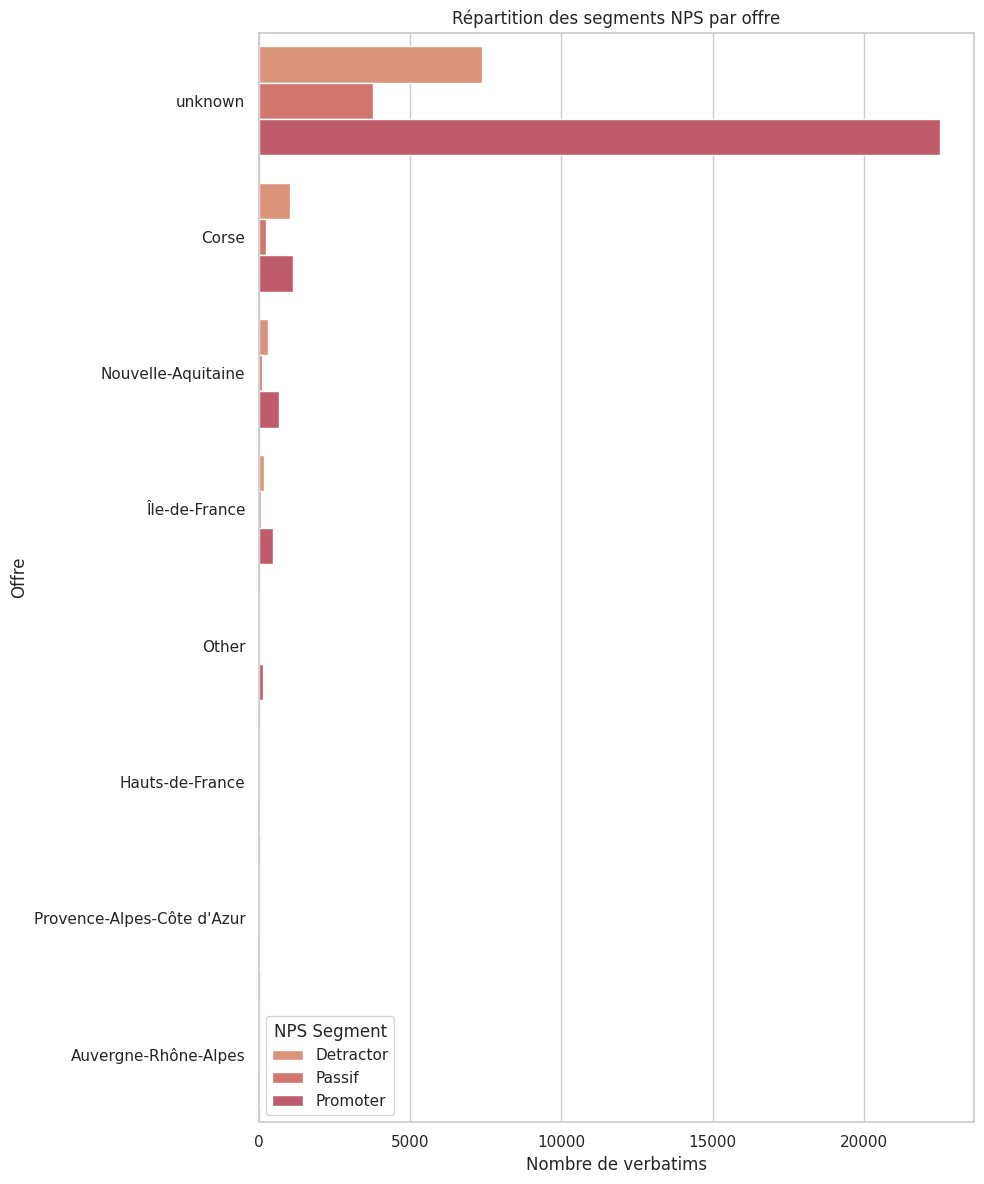

In [51]:
##
plt.figure(figsize=(10,12))
sns.countplot(
    data=df,
    y='nom_region',       # axe Y = les offres
    hue='nps_segment',
    order=df['nom_region'].value_counts().index,     # tri par nombre de verbatims
)

plt.title('Répartition des segments NPS par offre')
plt.xlabel('Nombre de verbatims')
plt.ylabel('Offre')
plt.legend(title='NPS Segment')
plt.tight_layout()
plt.show()


# EDA on commentaire


L’objectif de cette section est de comprendre la structure et les caractéristiques de la variable commentaire, afin d’identifier son influence sur la satifaction cliente et de comprendre les insight qui s'en dégage.
Pour cette partie je resterais assez basic avec NLTK et Sapcy

In [67]:
!pip install spacy download fr_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 3.5 MB/s eta 0:00:00


In [68]:
import nltk
import spacy
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
SEED = 42

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [69]:
#we will work for this EDA on just a smal part of the dataset let's say 10%
df_sample = df.groupby('nps_segment', group_keys= False).apply(lambda x: x.sample(frac=0.10, random_state=SEED)).reset_index(drop=True)

/tmp/ipython-input-3958068656.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('nps_segment', group_keys= False).apply(lambda x: x.sample(frac=0.10, random_state=SEED)).reset_index(drop=True)


In [70]:
#Ok nice the proportion are maintain
df_sample['nps_segment'].value_counts(normalize=True)

,proportion
nps_segment,
Promoter,0.654569
Detractor,0.234204
Passif,0.111227


In [71]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.6 MB/s eta 0:00:00


In [72]:
import re
import unidecode
def clean_text_and_norm(text:str) -> str:
  """
  """
  text = text.lower()
  text = unidecode.unidecode(text)
  text = re.sub(r"[^\w\s']", " ", text)
  text = re.sub(r"\s+", " ", text).strip()
  return text

In [73]:
test = df_sample['commentaire'][10]

In [74]:
clean_text_and_norm(test)

"en rebranchant ma fibre la fibre de mme jean leroy a ete deconnectee elle a demande aux techniciens de remettre tout comme avant ils n'ont pas repondu et sont partis laissant mme pierre thomas je n'ai recu aucune explication concernant notre panne et mme pierre martin n'a plus aucun service j'ai peur de la suite est ce que quand on depannera mme pierre thomas je garderai internet ou faudra t il encore vous appeler"

In [75]:
nlp = spacy.load("fr_core_news_sm")
stop_fr = set(stopwords.words("french"))

## Preprocessing text

In [76]:
class TextPreprocessor:
  def __init__(self, apply_lang_filter: bool =True, spell_check: bool =False, special_char_remove: bool =True, emoji_remove: bool =True, lemmatization: bool =True, stopword_remove: bool =True, apply_pos_tagging: bool =False, ner: bool =False)-> None:

    """

    """

    self.apply_pos_tagging = apply_lang_filter
    self.apply_lang_filter = apply_lang_filter
    self.spell_check=spell_check
    self.special_char_remove=special_char_remove
    self.emoji_remove = emoji_remove
    self.stopword_remove = stopword_remove
    self.lemmatization=lemmatization
    self.apply_pos_tagging=apply_pos_tagging
    self.ner = ner

  def clean_text(self, text: str) -> str:
    if not isinstance(text, str):
      return ""
    text = text.lower()
    text = unidecode.unidecode(text)
    if self.special_char_remove:
      text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

  def remove_stopwords(self, text: str) -> str:
    tokens = [w for w in text.split() if w not in stop_fr]
    return " ".join(tokens)

  def lemmatize_text(self, text: str) -> str:
    doc = nlp(text)
    lemmas = [tok.lemma_ for tok in doc if tok.lemma_ not in stop_fr]
    return " ".join(lemmas)

  def pos_taggin(self, text: str):
    doc = nlp(text)
    return [(tok.text, tok.pos_) for tok in doc]

  def extract_entities(self, text: str):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

  def preprocess(self, text: str) -> dict:
    if not text or not isinstance(text, str):
        return {"clean_text": None, "pos_tags": None, "entities": None}

    text = self.clean_text(text)

    if self.stopword_remove:
      text = self.remove_stopwords(text)

    if self.lemmatization:
      text = self.lemmatize_text(text)

    pos_tags = self.pos_taggin(text) if self.apply_pos_tagging else None
    entities = self.extract_entities(text) if self.ner else None

    return {
        "clean_text": text,
        "pos_tags": pos_tags,
        "entities": entities
    }


In [81]:
preprocessor = TextPreprocessor(apply_lang_filter= True, spell_check=False, stopword_remove=True, ner=True, apply_pos_tagging=True)
preprocessor.preprocess(test)

{'clean_text': "rebranchant fibre fibre mme jean leroy a ete deconnectee a demande techniciens remettre tout comme avant n'ont repondu partis laissant mme pierre thomas n'ai recu aucune explication concernant panne mme pierre martin n'a plus aucun service j'ai peur suite quand depannera mme pierre thomas garderai internet faudra encore appeler",
 'pos_tags': [('rebranchant', 'VERB'),
  ('fibre', 'NOUN'),
  ('fibre', 'NOUN'),
  ('mme', 'NOUN'),
  ('jean', 'PROPN'),
  ('leroy', 'PROPN'),
  ('a', 'AUX'),
  ('ete', 'ADV'),
  ('deconnectee', 'VERB'),
  ('a', 'AUX'),
  ('demande', 'VERB'),
  ('techniciens', 'ADJ'),
  ('remettre', 'VERB'),
  ('tout', 'ADV'),
  ('comme', 'ADP'),
  ('avant', 'ADP'),
  ("n'", 'ADV'),
  ('ont', 'AUX'),
  ('repondu', 'VERB'),
  ('partis', 'NOUN'),
  ('laissant', 'VERB'),
  ('mme', 'NOUN'),
  ('pierre', 'PROPN'),
  ('thomas', 'PROPN'),
  ("n'", 'ADV'),
  ('ai', 'AUX'),
  ('recu', 'VERB'),
  ('aucune', 'DET'),
  ('explication', 'NOUN'),
  ('concernant', 'VERB'),
  (

In [ ]:
class DatasetPreprocessor:
    def __init__(self, preprocessor):
        """
        """
        self.preprocessor = preprocessor

    def preprocess_comments(self, df: pd.DataFrame, comment_column: str) -> pd.DataFrame:
        """
        """
        # Appliquer le nettoyage de texte
        df['clean_commentaire'] = df[comment_column].apply(self.preprocessor.clean_text)

        # Appliquer la suppression des stopwords si activé
        df['clean_commentaire'] = df['clean_commentaire'].apply(
            lambda x: self.preprocessor.remove_stopwords(x) if self.preprocessor.stopword_remove else x
        )

        # Appliquer la lemmatisation si activé
        df['clean_commentaire'] = df['clean_commentaire'].apply(
            lambda x: self.preprocessor.lemmatize_text(x) if self.preprocessor.lemmatization else x
        )

        # Créer une colonne de tokens
        df['tokens'] = df['clean_commentaire'].apply(lambda x: x.split())

        return df

In [84]:
class DatasetPreprocessor:
    def __init__(self, preprocessor):
        """
        """
        self.preprocessor = preprocessor

    def preprocess_comments(self, df: pd.DataFrame, comment_column: str) -> pd.DataFrame:
        """
        """
        df['clean_commentaire'] = df[comment_column].apply(self.preprocessor.clean_text)
        df['clean_commentaire'] = df['clean_commentaire'].apply(
            lambda x: self.preprocessor.remove_stopwords(x) if self.preprocessor.stopword_remove else x
        )
        df['clean_commentaire'] = df['clean_commentaire'].apply(
            lambda x: self.preprocessor.lemmatize_text(x) if self.preprocessor.lemmatization else x
        )

        df['tokens'] = df['clean_commentaire'].apply(lambda x: x.split())

        return df

In [85]:
df_preprocessor = DatasetPreprocessor(preprocessor)
df_sample = df_preprocessor.preprocess_comments(df_sample, 'commentaire')

In [86]:
df_sample.head()

,date_contact,csat,nps,nom_departement,nom_region,du_societe_label,canal,offer_label,commentaire,nps_segment,text_raw,clean_commentaire,tokens
0,2025-10-10,1,0,unknown,unknown,unknown,unknown,24: Freebox Pop | 39.99€,J'avais posé 2 questions : \n1) le débit faib...,Detractor,j'avais pose 2 questions 1 le debit faible le ...,j'avais pose 2 questions 1 debit faible debit ...,"[j'avais, pose, 2, questions, 1, debit, faible..."
1,2025-10-22,1,0,unknown,unknown,TP Tunis,unknown,unknown,"Bonjour, j'ai bien conscience des informations...",Detractor,bonjour j'ai bien conscience des informations ...,bonjour j'ai bien conscience informations ment...,"[bonjour, j'ai, bien, conscience, informations..."
2,2025-10-22,3,3,unknown,unknown,unknown,unknown,11: Freebox Révolution avec TV by CANAL | 39.99€,A ce jour je paie un abonnement pour un servic...,Detractor,a ce jour je paie un abonnement pour un servic...,a jour paie abonnement service n'ai exemple re...,"[a, jour, paie, abonnement, service, n'ai, exe..."
3,2025-10-14,2,1,unknown,unknown,VIPP Interstis,unknown,unknown,Sim activée sans mon consentement ni m'informe...,Detractor,sim activee sans mon consentement ni m'informe...,sim activee sans consentement ni m'informer re...,"[sim, activee, sans, consentement, ni, m'infor..."
4,2025-10-10,1,0,unknown,unknown,unknown,unknown,24: Freebox Pop | 39.99€,Vous ne pouvez pas mettre un numéro où on peut...,Detractor,vous ne pouvez pas mettre un numero ou on peut...,pouvez mettre numero peut joindre directement ...,"[pouvez, mettre, numero, peut, joindre, direct..."


In [91]:
df_sample['tokens'].apply(len).describe()

,tokens
count,3830.000000
mean,12.779112
std,15.802641
min,0.000000
25%,3.000000
50%,7.000000
75%,15.000000
max,136.000000


Text(0, 0.5, 'Com number')

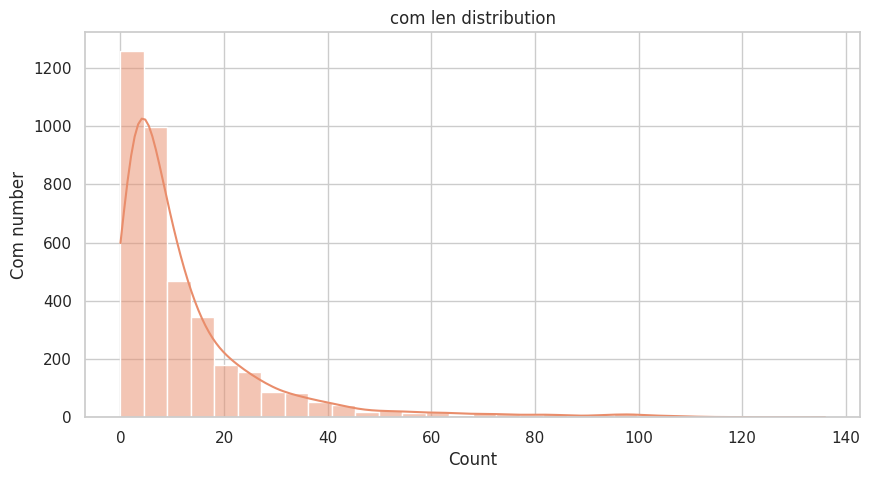

In [89]:
plt.figure(figsize=(10, 5))
sns.histplot(df_sample['tokens'].apply(len), bins=30, kde=True)
plt.title('com len distribution')
plt.xlabel('Count')
plt.ylabel('Com number')

La longueur des token montre que les verbatims restent assez court avec une moyenne de 12 token et une dispersion plus tot eleve si on regarde l'ecart type, cela peut sugèrer que les personnes comme les detractors on plus tendance a faire des commentaire plus long il faut voir la distribution en fonction des segments

/tmp/ipython-input-3576256394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='nps_segment', y=df_sample['tokens'].apply(len), data=df_sample, palette="Set2", inner="quartile")


Text(0, 0.5, 'Count')

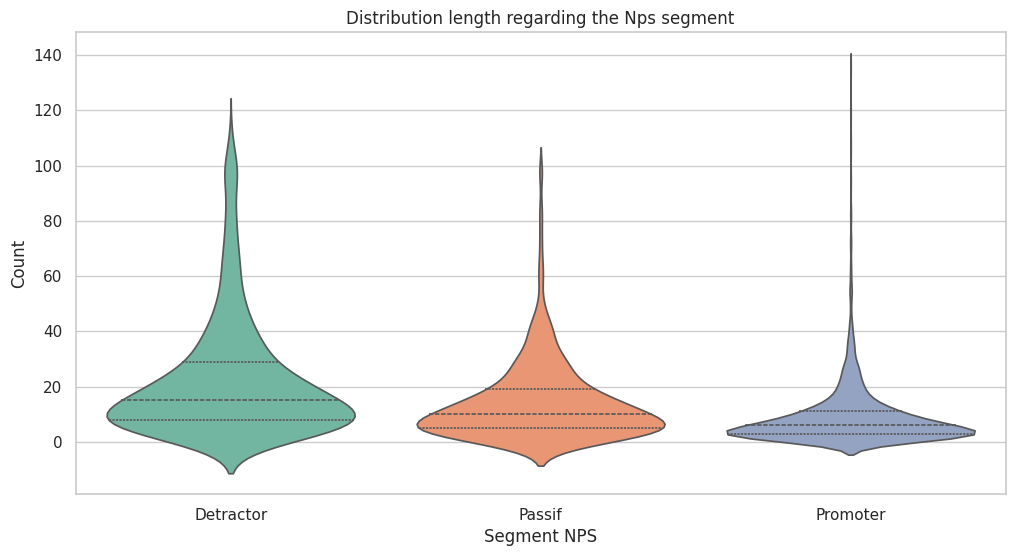

In [92]:
plt.figure(figsize=(12,6))
sns.violinplot(x='nps_segment', y=df_sample['tokens'].apply(len), data=df_sample, palette="Set2", inner="quartile")
plt.title('Distribution length regarding the Nps segment')
plt.xlabel('Segment NPS')
plt.ylabel('Count')

C'est bien se qui me semblait la distribution est plus étalé vers les valeurs élées on a des commentaires plus long et plus détaillé quand les clients sont insatisfait. pour les Promoteurs la ditribution reste assez centré et concis. Regardons maintenant les mots les plus récurrants

/tmp/ipython-input-4000059182.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  text = " ".join(df_sample[df['nps_segment'] == s]['clean_commentaire'])
/tmp/ipython-input-4000059182.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  text = " ".join(df_sample[df['nps_segment'] == s]['clean_commentaire'])
/tmp/ipython-input-4000059182.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  text = " ".join(df_sample[df['nps_segment'] == s]['clean_commentaire'])


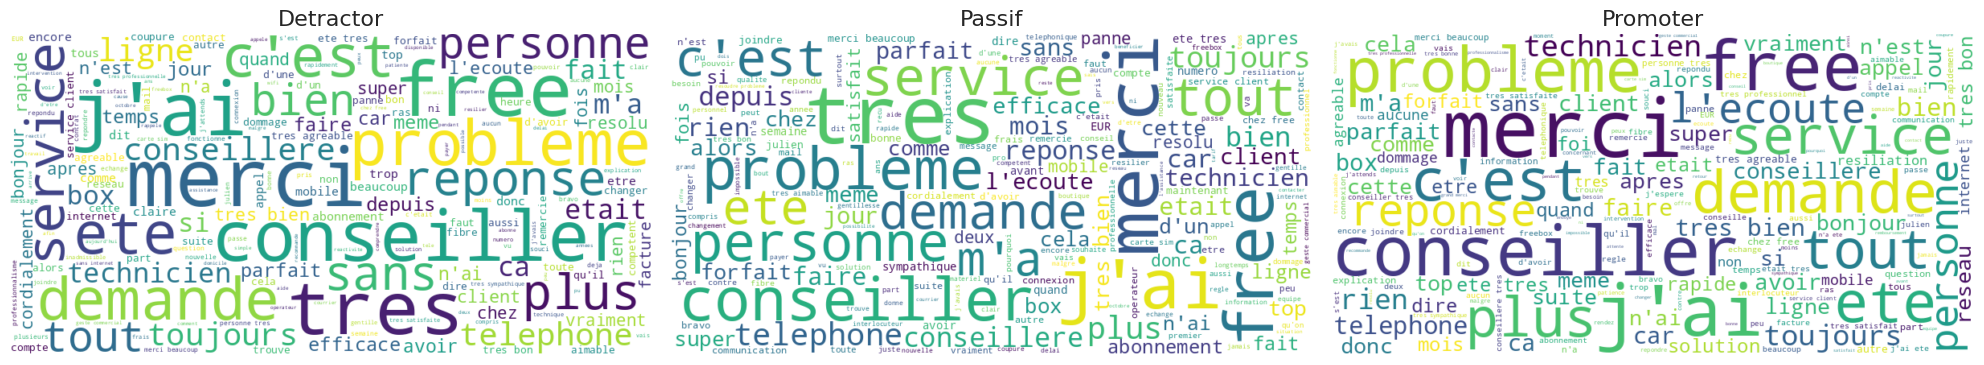

In [93]:
## wordcloud
from wordcloud import WordCloud

plt.figure(figsize=(20, 10))
segments = df_sample['nps_segment'].unique()
for i, s in enumerate(segments , 1):
  text = " ".join(df_sample[df['nps_segment'] == s]['clean_commentaire'])
  wordcloud = WordCloud(
      width=800,
      height=400,
      max_font_size=100,
      background_color = 'white'
  ).generate(text)
  plt.subplot(1, len(segments), i)
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(f'{s}', fontsize=16)
plt.tight_layout()



Les mots problème, merci, conseiller on l'air de revenir assez souvent mais il faudrais plus de contexte pour mieux cibler ce qui fait le mécontentement des utilisateur. On vas se tourner vers un n-gramm qui sera plus optimal pour avoir du context sur les verbatims

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from typing import List, Tuple
def top_ngrams(corpus: List[str], ngram_range: Tuple[int,int]=(2,2), top_n: int=10) -> List[Tuple[str,int]]:
  """
  """
  vec = CountVectorizer(ngram_range=ngram_range, stop_words=list(stop_fr))
  X = vec.fit_transform(corpus)
  sum_words = X.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
  return words_freq[:top_n]

In [ ]:
corpus = df_sample['clean_commentaire'].tolist()
top_bigrams = top_ngrams(corpus, ngram_range=(3,3), top_n=15)
print(top_bigrams)

[('avoir ete tre', np.int64(81)), ('tre avoir ecoute', np.int64(53)), ('rien avoir dire', np.int64(51)), ('conseiller avoir ete', np.int64(30)), ('avoir ecoute avoir', np.int64(26)), ('avoir repondu avoir', np.int64(25)), ('avoir ecoute tre', np.int64(24)), ('grand merci avoir', np.int64(21)), ('tre bon accueil', np.int64(20)), ('personn tre agreabl', np.int64(18)), ('conseiller avoir ecoute', np.int64(17)), ('conseillere avoir ete', np.int64(17)), ('avoir tre bien', np.int64(17)), ('avoir ete resolu', np.int64(16)), ('avoir chaque fois', np.int64(15))]


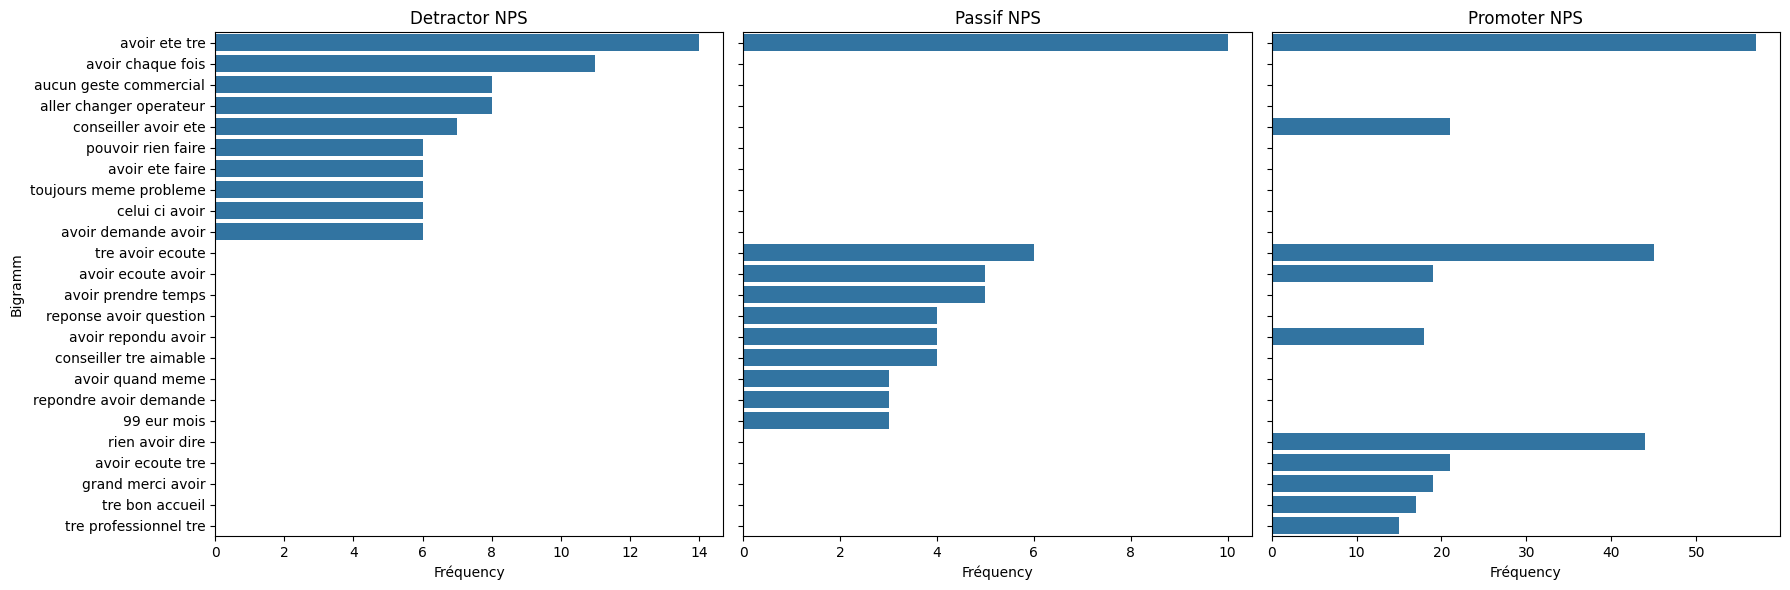

In [ ]:
segments = df_sample['nps_segment'].unique()
fig, axes = plt.subplots(1, len(segments), figsize=(18,6), sharey=True)

for i, s in enumerate(segments):
    corpus_seg = df_sample[df_sample['nps_segment'] == s]['clean_commentaire'].tolist()
    top_bigrams = top_ngrams(corpus_seg, ngram_range=(3,3), top_n=10)
    df_bigrams = pd.DataFrame(top_bigrams, columns=['bigram', 'count'])

    sns.barplot(data=df_bigrams, y='bigram', x='count', ax=axes[i])
    axes[i].set_title(f"{s} NPS")
    axes[i].set_xlabel("Fréquency")
    if i == 0:
        axes[i].set_ylabel("Bigramm")
    else:
        axes[i].set_ylabel("")

plt.tight_layout()